## Applied Quantum Computing Lab Course Winter Term 25/26

### Solution for Lab 4: Logical Quantum Gates (10/31/2025)

2-Qubit quantum gates can be used in Qiskit as follows. Note the different visualization in ``draw``.

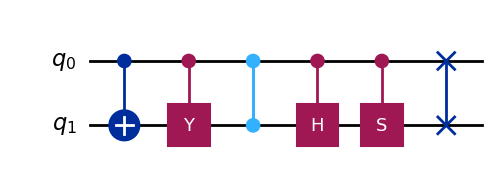

In [29]:
from qiskit import QuantumCircuit

quantum_circuit = QuantumCircuit(2)
quantum_circuit.cx(0, 1) # CNOT / Controlled X-Gate with control qubit 0 and target qubit 1
quantum_circuit.cy(0, 1) # Controlled Y-Gate with control qubit 0 and target qubit 1
quantum_circuit.cz(0, 1) # Controlled Z-Gate with control qubit 0 and target qubit 1
quantum_circuit.ch(0, 1) # Controlled H-Gate with control qubit 0 and target qubit 1
quantum_circuit.cs(0, 1) # Controlled S-Gate with control qubit 0 and target qubit 1
quantum_circuit.swap(0, 1) # SWAP-Gate between qubit 0 and qubit 1
display(quantum_circuit.draw('mpl'))

Qubits with multiple controls can be implemented as follows:

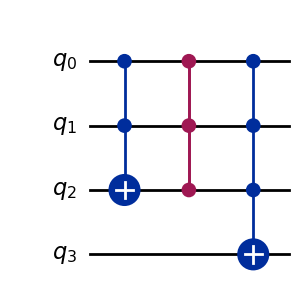

In [30]:
quantum_circuit = QuantumCircuit(4)
quantum_circuit.ccx(0, 1, 2) # Toffoli-Gate with control qubits 0, 1 and target qubit 2
quantum_circuit.ccz(0, 1, 2) # Doubly Controlled Z-Gate with control qubits 0, 1 and target qubit 2
quantum_circuit.mcx(control_qubits=[0, 1,2], target_qubit=3) # Multi-CNOT Gate with control qubits 0, 1, 2 and target qubit 3
display(quantum_circuit.draw('mpl'))

### Exercise 1: Controlling Quantum Gates

The Bell state $\ket{\Psi} = \frac{\sqrt{2}}{2}\ket{00} + \frac{\sqrt{2}}{2}\ket{11}$ can be implemented as follows:

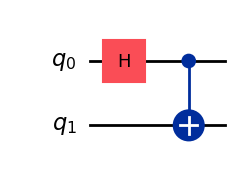

<IPython.core.display.Math object>

In [31]:
from qc_lecture_tools.statevector import sv_state

quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
quantum_circuit.cx(0, 1)
display(quantum_circuit.draw('mpl'))
display(sv_state(quantum_circuit, "Quantum State: "))

**Exercise 1.1:** Find a circuit to create the following quantum state: $\ket{\Psi} = \frac{\sqrt{2}}{2} \ket{01} + \frac{\sqrt{2}}{2}\ket{10}$

In [32]:
# TODO Exercise 1.1

**Exercise 1.2:** Find a circuit that prepares the following state: $\Psi = \frac{\sqrt{2}}{2} \ket{01} + \frac{\sqrt{2}i}{2}\ket{11}$

In [33]:
# TODO Exercise 1.2

**Exercise 1.3:** Why does it not matter which qubit is the target and which is the control for the controlled Z-gate? Look at the effect on all quantum states (uniform superposition is sufficient).

In [34]:
# TODO Exercise 1.3

**Exercise 1.4:** Investigate the effect of the SWAP gate on the individual basis states $\ket{00},\ldots,\ket{11}$.
What happens after the individual CNOT gates?

The SWAP gate can be implemented by three consecutive CNOT gates. The control and target qubits alternate.

In [35]:
# TODO Exercise 1.4

### Exercise 2: Implementation of Classical Logical Gates

**Exercise:** Realize the known classical gates like AND, XOR, OR, and NAND as well as an equality check (=) using quantum gates.
Three qubits are used for the implementation: the first two qubits serve as input (A and B), the third qubit as the output of the gate.
You only need the X, CX, and CCX gates.

To analyze the effect of the gate, apply your implementation to the uniformly distributed superposition state:

$\ket{\Psi} = \frac{1}{2} \ket{000} + \frac{1}{2} \ket{010} + \frac{1}{2} \ket{100} + \frac{1}{2} \ket{110}$

**Hint:** The logic gates have the following definition

<table>
<tr>
<td>

**AND**

|  A |  B |  A AND B |
|---------|---------|------------------|
|    0    |    0    |        0         |
|    0    |    1    |        0         |
|    1    |    0    |        0         |
|    1    |    1    |        1         |

</td>
<td>

**XOR**

|  A |  B |  A XOR B |
|---------|---------|------------------|
|    0    |    0    |        0         |
|    0    |    1    |        1         |
|    1    |    0    |        1         |
|    1    |    1    |        0         |

</td>
<td>

**OR**

|  A |  B |  A OR B  |
|---------|---------|------------------|
|    0    |    0    |        0         |
|    0    |    1    |        1         |
|    1    |    0    |        1         |
|    1    |    1    |        1         |

</td>
<td>

**NAND**

|  A |  B |  A NAND B|
|---------|---------|------------------|
|    0    |    0    |        1         |
|    0    |    1    |        1         |
|    1    |    0    |        1         |
|    1    |    1    |        0         |

</td>
<td>

**Equality (=)**

|  A |  B |  A = B   |
|---------|---------|------------------|
|    0    |    0    |        1         |
|    0    |    1    |        0         |
|    1    |    0    |        0         |
|    1    |    1    |        1         |

</td>
</tr>
</table>

To quickly verify the gate implementation, we use a uniformly distributed superposition of the first two qubits:

In [36]:
# We first define the superposition circuit
qc_test = QuantumCircuit(3)
qc_test.h(0)
qc_test.h(1)
sv_state(qc_test, "Input State:")

<IPython.core.display.Math object>

Circuits in Qiskit can be appended one after another using the ``compose`` function:

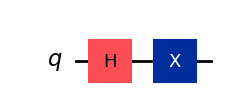

In [37]:
# Circuit 1
quantum_circuit1 = QuantumCircuit(1)
quantum_circuit1.h(0)

# Circuit 2
quantum_circuit2 = QuantumCircuit(1)
quantum_circuit2.x(0)

# Circuit 1 + Circuit 2
quantum_circuit3 = quantum_circuit1.compose(quantum_circuit2)
display(quantum_circuit3.draw('mpl'))

**Exercise 2.1:** AND Gate

In [38]:
# TODO Exercise 2.1

**Exercise 2.2:** XOR Gate

In [39]:
# TODO Exercise 2.2

**Exercise 2.3:** OR Gate

In [40]:
# TODO Exercise 2.3

**Exercise 2.4:** NAND Gate

In [41]:
# TODO Exercise 2.4

**Exercise 2.5:** Equality (=)

In [42]:
# TODO Exercise 2.5

### Exercise 3: More Complex Logical Implementations

Now we generalize what we learned in Exercise 2. We have given data qubits in the Exercise.
For these, we implement various logical queries and store the result in an additional qubit.

**Example:** 2 data qubits and the query whether exactly one bit of the data qubits is equal to 1.

In [43]:
# Data qubits superposition:
qc_data = QuantumCircuit(3)
qc_data.h(0)
qc_data.h(1)

# Implementation works here with XOR
qc_check = QuantumCircuit(3)
qc_check.cx(0,2)
qc_check.cx(1,2)

print("State before the check:")
display(sv_state(qc_data))
print("State after the check:")
display(sv_state(qc_data.compose(qc_check)))

State before the check:


<IPython.core.display.Math object>

State after the check:


<IPython.core.display.Math object>

The third qubit stores whether only a single 1 appears in the first two qubits.

**Exercise 3.1:** We have two data qubits. The goal is to check if the two data qubits are in the state 0. ($\ket{000} \rightarrow \ket{001}$, all others unchanged)

In [44]:
# TODO Exercise 3.1

**Exercise 3.2:** Now the same with three data qubits ($\ket{0000} \rightarrow \ket{0001}$, all others unchanged)

In [45]:
# TODO Exercise 3.2

**Exercise 3.3:** Now we combine two queries for three data qubits: 

* Condition 1: The first and second qubit are not equal to 11
* Condition 2: The second and third qubit are not equal to 00.

Correct states are now those where both conditions are met at once. 

There are now several correct possibilities: 001, 101, ...  <!--010, 011 -->

**Hint:** Here, several logical queries must be combined. (More Ancilla Qubits)

In [46]:
# TODO Exercise 3.3

### Bonus Exercise: Sudoku

Given is the following 2x2 Sudoku (order of numbers does not matter)
 
| ? | 4 | 
|---|---|
| **2** | ? |

A valid solution is given if every number appears only once in the free spaces of the box. We neglect multiple boxes as it quickly requires too many bits.

We represent the numbers with two bits:

- 1 &rarr; 00
- 2 &rarr; 01
- 3 &rarr; 10
- 4 &rarr; 11

Wanted is a query that stores in an Ancilla Qubit whether the solution is correct.
For this we have a bitstring with 4 entries: $\ket{q_0q_1 ~ q_2q_3}$
The first number is given by the bits $q_0q_1$, the second number by the bits $q_2q_3$.

It is obvious that the missing numbers are 1 and 3. However, the query should not be: is the bitstring $q_0q_1q_2q_3$ equal to 1000 or 0010, because the solution would then be known.

Instead, we must query the conditions of the Sudoku:
- The unknown numbers are not 2 and not 4
- Each unknown number appears only once

The query for this example will require significantly more than one additional Ancilla Qubit.

In [47]:
# Helper function for statevector output
from qc_lecture_tools.statevector import sv_array
import numpy as np

def print_sudoku_states(quantum_circuit):
    statevector = sv_array(quantum_circuit)
    print("Found bitstrings in the quantum state with non-zero amplitudes:")
    for i,amplitude in enumerate(statevector):
        if np.abs(amplitude)>1e-10:
            # Conversion from integer values to bitstrings
            bitstr = format(i, f'0{quantum_circuit.num_qubits}b')
            print(f"{bitstr[:2]} {bitstr[2:4]} {bitstr[4:-1]} {bitstr[-1]}  ")

In [48]:
qc_data = QuantumCircuit(12)
qc_data.h([0,1,2,3])

qc_check = QuantumCircuit(12)

# Output the bitstrings that appear in the quantum state with non-zero amplitudes
# Suitable formatting of the output (with spaces between the numbers and the last qubit for verification)
print_sudoku_states(qc_data.compose(qc_check))

Found bitstrings in the quantum state with non-zero amplitudes:
00 00 0000000 0  
00 01 0000000 0  
00 10 0000000 0  
00 11 0000000 0  
01 00 0000000 0  
01 01 0000000 0  
01 10 0000000 0  
01 11 0000000 0  
10 00 0000000 0  
10 01 0000000 0  
10 10 0000000 0  
10 11 0000000 0  
11 00 0000000 0  
11 01 0000000 0  
11 10 0000000 0  
11 11 0000000 0  
